<a href="https://colab.research.google.com/github/Lu161616/Lu/blob/main/PrediccionColombiaVsCongo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install xgboost scipy pandas numpy matplotlib seaborn


In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
from scipy.stats import poisson
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [10]:
# Cargar el dataset oficial y actualizado
REPO_URL = 'https://raw.githubusercontent.com/martj42/international_results/master/results.csv'
print(f"Descargando datos desde: {REPO_URL}...")

df_raw = pd.read_csv(REPO_URL)
df_raw['date'] = pd.to_datetime(df_raw['date'])

print(f"Total de partidos descargados: {len(df_raw)}")

Descargando datos desde: https://raw.githubusercontent.com/martj42/international_results/master/results.csv...
Total de partidos descargados: 49477


In [11]:
# --- CONFIGURACIÓN DEL PARTIDO ---
HOME_TEAM = 'Colombia'
AWAY_TEAM = 'Congo'  # Nota: Si te da error más adelante, cámbialo a 'DR Congo'
MATCH_DATE = pd.Timestamp('2026-06-23') # Próximo martes
HOME_IS_HOST = False # True si se juega en Colombia, False si es en otro país (Neutral)

# Entrenaremos con datos desde 2018 para reflejar el rendimiento contemporáneo
FECHA_INICIO = pd.Timestamp('2018-01-01')

print(f"Configurado: {HOME_TEAM} vs {AWAY_TEAM} para el {MATCH_DATE.strftime('%Y-%m-%d')}")

Configurado: Colombia vs Congo para el 2026-06-23


In [12]:
# Filtrar por fecha
df = df_raw[df_raw['date'] >= FECHA_INICIO].copy()

# Preparar datos en formato "largo" para regresión de Poisson
# Datos de los equipos que juegan de "Local" o en el primer slot
home_data = pd.DataFrame({
    'team': df['home_team'],
    'opponent': df['away_team'],
    'is_home': 1 if HOME_IS_HOST else 0, # Pesa si es local real
    'neutral': df['neutral'].astype(int),
    'goals': df['home_score']
})

# Datos de los equipos que juegan de "Visitante" o en el segundo slot
away_data = pd.DataFrame({
    'team': df['away_team'],
    'opponent': df['home_team'],
    'is_home': 0,
    'neutral': df['neutral'].astype(int),
    'goals': df['away_score']
})

# Unir ambos datasets
df_poisson = pd.concat([home_data, away_data], ignore_index=True)
df_poisson = df_poisson.dropna()

# One-Hot Encoding para los nombres de los países
X = df_poisson[['team', 'opponent', 'is_home', 'neutral']]
y = df_poisson['goals']
X_encoded = pd.get_dummies(X)

print("Datos listos para entrenar. Entradas (Features) creadas.")

Datos listos para entrenar. Entradas (Features) creadas.


In [13]:
print("Entrenando modelo XGBoost (Regresión de Poisson)...")

# Configurar el modelo para que el objetivo (objective) sea la distribución de Poisson
modelo_xgb = xgb.XGBRegressor(
    objective='count:poisson',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

modelo_xgb.fit(X_encoded, y)
print("¡Modelo entrenado exitosamente!")

Entrenando modelo XGBoost (Regresión de Poisson)...
¡Modelo entrenado exitosamente!


Goles esperados calculados: Colombia 1.33 - 1.33 Congo

--- RESUMEN DE PROBABILIDADES ---
Victoria Colombia: 36.7%
Empate: 26.1%
Victoria Congo: 36.7%



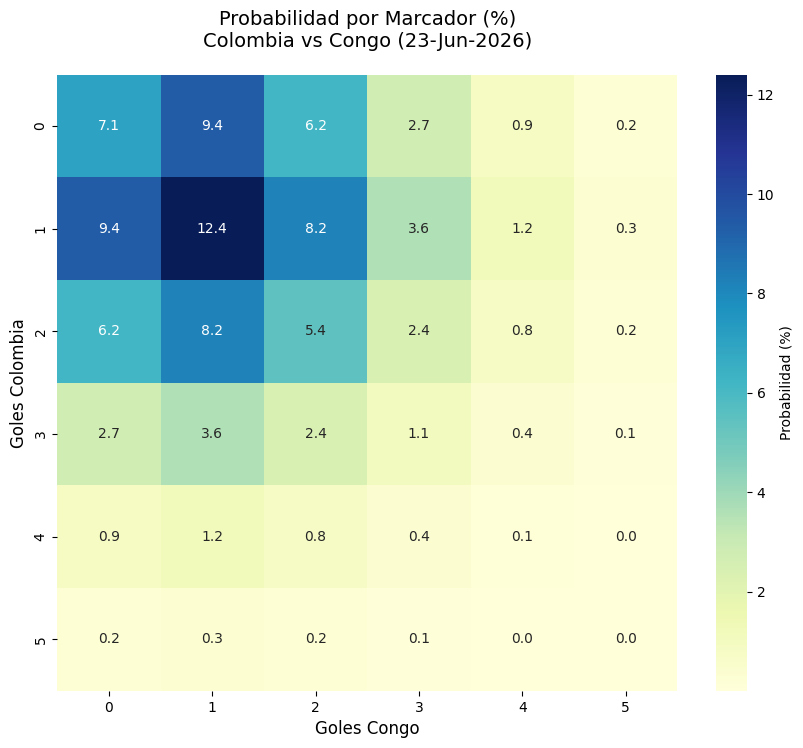

In [14]:
# 1. Preparar las características del partido a predecir
# Expectativa de goles para Colombia
col_features = pd.DataFrame({'team': [HOME_TEAM], 'opponent': [AWAY_TEAM], 'is_home': [1 if HOME_IS_HOST else 0], 'neutral': [1 if not HOME_IS_HOST else 0]})
# Expectativa de goles para Congo
con_features = pd.DataFrame({'team': [AWAY_TEAM], 'opponent': [HOME_TEAM], 'is_home': [0], 'neutral': [1 if not HOME_IS_HOST else 0]})

# Alinear con las columnas de entrenamiento
col_encoded = pd.get_dummies(col_features).reindex(columns=X_encoded.columns, fill_value=0)
con_encoded = pd.get_dummies(con_features).reindex(columns=X_encoded.columns, fill_value=0)

# 2. Predecir los "Goles Esperados" (Expected Goals - xG)
xg_colombia = modelo_xgb.predict(col_encoded)[0]
xg_congo = modelo_xgb.predict(con_encoded)[0]

print(f"Goles esperados calculados: Colombia {xg_colombia:.2f} - {xg_congo:.2f} Congo\n")

# 3. Crear la Matriz de Marcadores usando Distribución de Poisson
max_goles = 6 # Calcularemos hasta un 5-5
prob_matriz = np.zeros((max_goles, max_goles))

for i in range(max_goles): # Goles Colombia
    for j in range(max_goles): # Goles Congo
        prob_matriz[i, j] = poisson.pmf(i, xg_colombia) * poisson.pmf(j, xg_congo)

# 4. Visualizar el Heatmap (Matriz de marcadores)
plt.figure(figsize=(10, 8))
sns.heatmap(
    prob_matriz * 100, # Convertir a porcentaje
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Probabilidad (%)'}
)

plt.title(f"Probabilidad por Marcador (%)\n{HOME_TEAM} vs {AWAY_TEAM} ({MATCH_DATE.strftime('%d-%b-%Y')})", pad=20, fontsize=14)
plt.xlabel(f"Goles {AWAY_TEAM}", fontsize=12)
plt.ylabel(f"Goles {HOME_TEAM}", fontsize=12)

# Analizar quién tiene más probabilidades de ganar
prob_col = np.tril(prob_matriz, -1).sum() * 100
prob_empate = np.trace(prob_matriz) * 100
prob_con = np.triu(prob_matriz, 1).sum() * 100

print(f"--- RESUMEN DE PROBABILIDADES ---")
print(f"Victoria Colombia: {prob_col:.1f}%")
print(f"Empate: {prob_empate:.1f}%")
print(f"Victoria Congo: {prob_con:.1f}%\n")

plt.show()

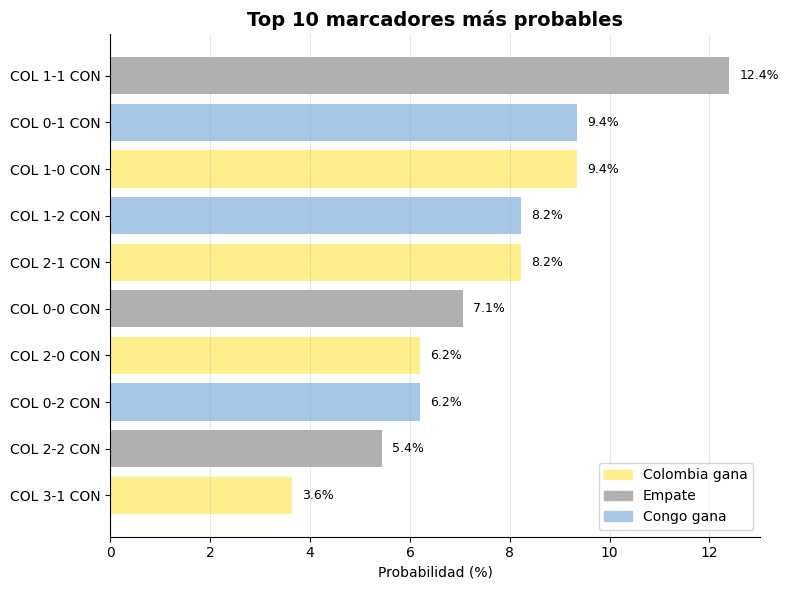

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Extraer todas las probabilidades de la matriz
marcadores = []
for i in range(max_goles): # Goles Colombia (Home)
    for j in range(max_goles): # Goles Congo (Away)
        prob = prob_matriz[i, j] * 100

        # Asignar colores según el resultado
        if i > j:
            resultado = f'{HOME_TEAM} gana'
            color = '#FFEE8C' # amarillo
        elif i == j:
            resultado = 'Empate'
            color = '#B0B0B0' # Gris
        else:
            resultado = f'{AWAY_TEAM} gana'
            color = '#A7C7E7' # azul

        marcadores.append({
            'marcador': f'COL {i}-{j} CON',
            'probabilidad': prob,
            'resultado': resultado,
            'color': color
        })

# 2. Convertir a DataFrame, ordenar de mayor a menor y sacar el Top 10
df_marcadores = pd.DataFrame(marcadores)
df_top10 = df_marcadores.sort_values(by='probabilidad', ascending=False).head(10)

# Invertir el orden del DataFrame para que el más probable quede arriba en el gráfico
df_top10 = df_top10.iloc[::-1]

# 3. Crear el gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(8, 6))
barras = ax.barh(df_top10['marcador'], df_top10['probabilidad'], color=df_top10['color'])

# 4. Añadir las etiquetas de porcentaje al final de cada barra
for barra in barras:
    ancho = barra.get_width()
    ax.text(ancho + 0.2, barra.get_y() + barra.get_height()/2,
            f'{ancho:.1f}%',
            va='center', fontsize=9)

# 5. Configuraciones estéticas (ejes, título y fondo)
ax.set_xlabel('Probabilidad (%)')
ax.set_title('Top 10 marcadores más probables', fontweight='bold', fontsize=14)
ax.grid(axis='x', linestyle='-', alpha=0.3) # Líneas de cuadrícula suaves
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


leyenda_local = mpatches.Patch(color='#FFEE8C', label=f'{HOME_TEAM} gana')
leyenda_empate = mpatches.Patch(color='#B0B0B0', label='Empate')
leyenda_visitante = mpatches.Patch(color='#A7C7E7', label=f'{AWAY_TEAM} gana')
ax.legend(handles=[leyenda_local, leyenda_empate, leyenda_visitante], loc='lower right')

plt.tight_layout()
plt.show()